<a href="https://colab.research.google.com/github/TheVailen/frameworks-lab1-ml-pipeline/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорты и чтение датасета


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder


df = pd.read_csv('student_lifestyle_100k.csv')

# 1. Разведочный анализ (EDA)

Текстовая информация

In [6]:
print("Размер датасета")
print(df.shape)

print("\nТипы данных")
print(df.dtypes)

print("\nПервые 5 строк таблицы")
df.head()

Размер датасета
(100000, 11)

Типы данных
Student_ID              int64
Age                     int64
Gender                 object
Department             object
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object

Первые 5 строк таблицы


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [7]:
print("\nПропуски")
print(df.isnull().sum())

print("\nКоличество дубликатов")
print(df.duplicated().sum())

print("\nСтатистика по столбцам с числами")
df.describe()


Пропуски
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Количество дубликатов
0

Статистика по столбцам с числами


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


# Гистограммы со столбцами из датасета

# Age


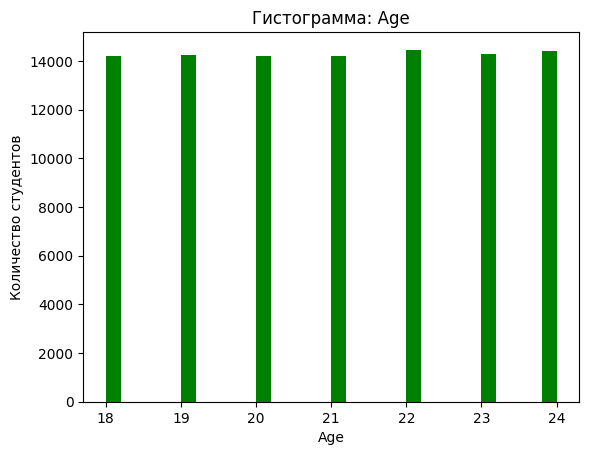

In [8]:
plt.hist(df['Age'], bins=30, color='green')
plt.title("Гистограмма: Age")
plt.xlabel("Age")
plt.ylabel("Количество студентов")
plt.show()

# CGPA

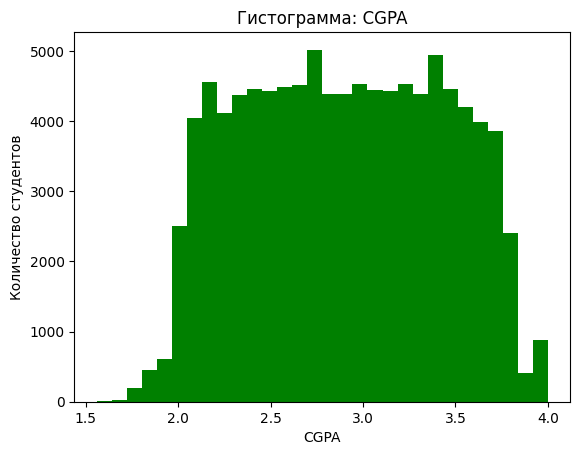

In [9]:
plt.hist(df['CGPA'], bins=30, color='green')
plt.title("Гистограмма: CGPA")
plt.xlabel("CGPA")
plt.ylabel("Количество студентов")
plt.show()

# Sleep Duration

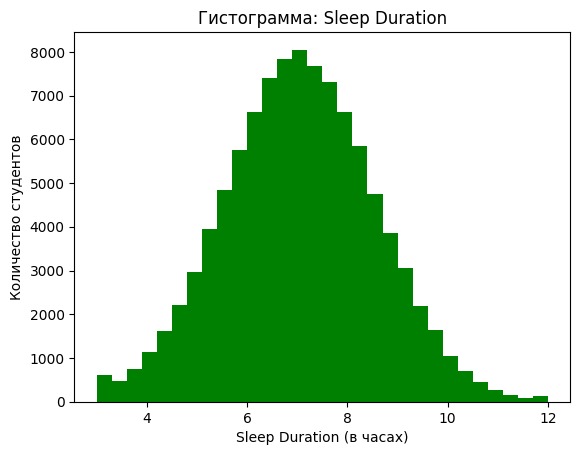

In [10]:
plt.hist(df["Sleep_Duration"], bins=30, color="green")
plt.title("Гистограмма: Sleep Duration")
plt.xlabel("Sleep Duration (в часах)")
plt.ylabel("Количество студентов")
plt.show()

# Study Hours

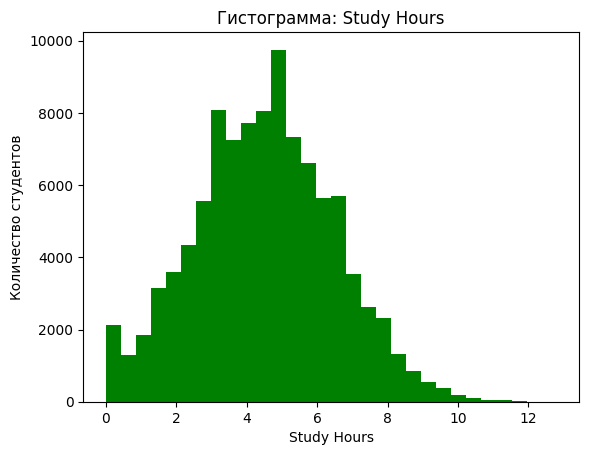

In [11]:
plt.hist(df['Study_Hours'], bins=30, color='green')
plt.title('Гистограмма: Study Hours')
plt.xlabel("Study Hours")
plt.ylabel("Количество студентов")
plt.show()

# Social Media Hours

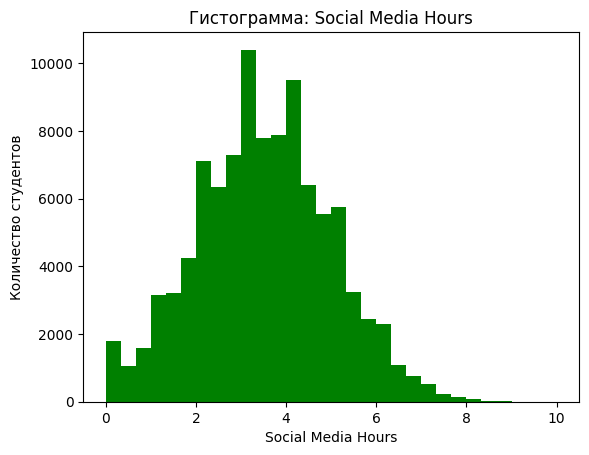

In [12]:
plt.hist(df['Social_Media_Hours'], bins=30, color='green')
plt.title('Гистограмма: Social Media Hours')
plt.xlabel('Social Media Hours')
plt.ylabel('Количество студентов')
plt.show()

# Physical Activity

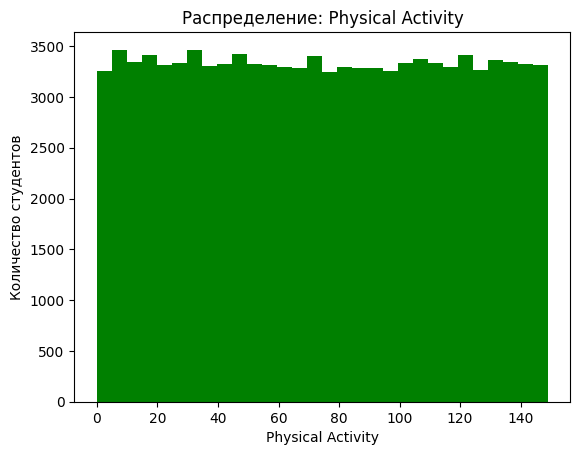

In [13]:
plt.hist(df['Physical_Activity'], bins=30, color='green')
plt.title('Распределение: Physical Activity')
plt.xlabel('Physical Activity')
plt.ylabel('Количество студентов')
plt.show()

# Stress Level

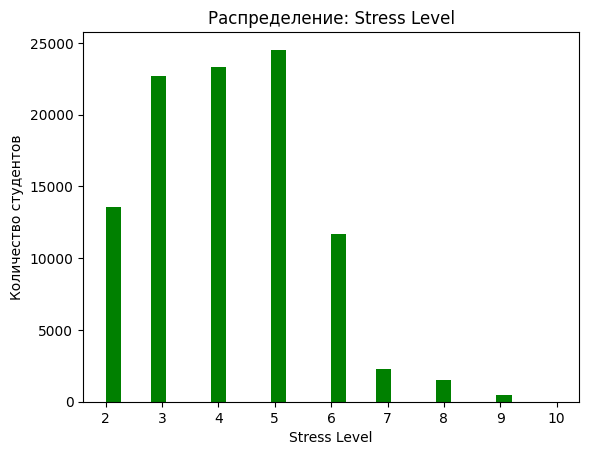

In [14]:
plt.hist(df['Stress_Level'], bins=30, color='green')
plt.title('Распределение: Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Количество студентов')
plt.show()

## BOXPLOT

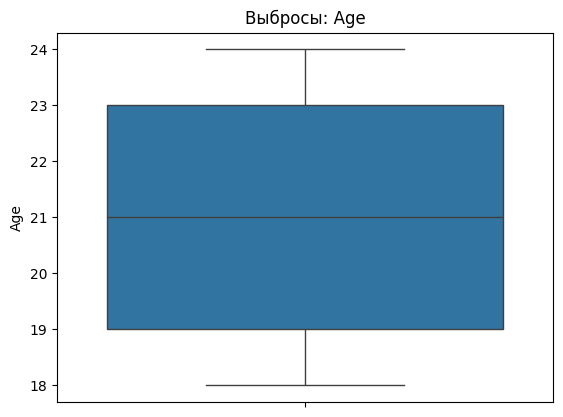

In [15]:
sns.boxplot(y=df['Age'])
plt.title('Выбросы: Age')
plt.show()

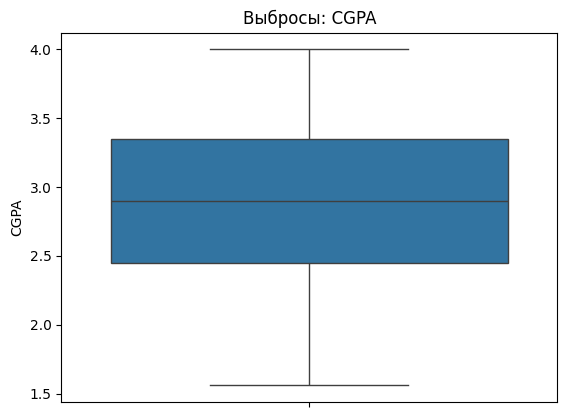

In [16]:
sns.boxplot(y=df['CGPA'])
plt.title('Выбросы: CGPA')
plt.show()

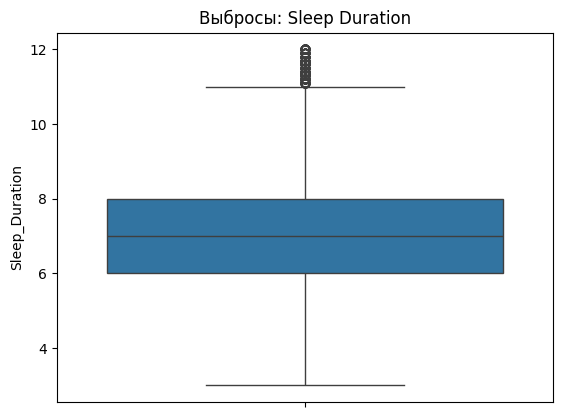

Минимум Sleep_Duration: 3.0
Максимум Sleep_Duration: 12.0

Значения выше 11 часов:
Sleep_Duration
11.1    63
11.2    53
11.3    46
11.4    35
11.5    30
11.6    20
11.7    26
11.8    22
11.9    12
12.0    62
Name: count, dtype: int64


In [17]:
sns.boxplot(y=df['Sleep_Duration'])
plt.title('Выбросы: Sleep Duration')
plt.show()

print(f"Минимум Sleep_Duration: {df['Sleep_Duration'].min()}")
print(f"Максимум Sleep_Duration: {df['Sleep_Duration'].max()}")
print(f"\nЗначения выше 11 часов:")
print(df[df['Sleep_Duration'] > 11]['Sleep_Duration'].value_counts().sort_index())

Вывод по sleep duration: Значения Sleep_Duration от 11.1 до 12.0 часов формально являются
выбросами по методу IQR, однако физически возможны. Таких записей 369 (<0.4% датасета).

Решение: оставить как есть - удаление этих данных ухудшит качество модели, особенно учитывая что депрессия является целевой переменной и долгий сон может быть с ней связан.

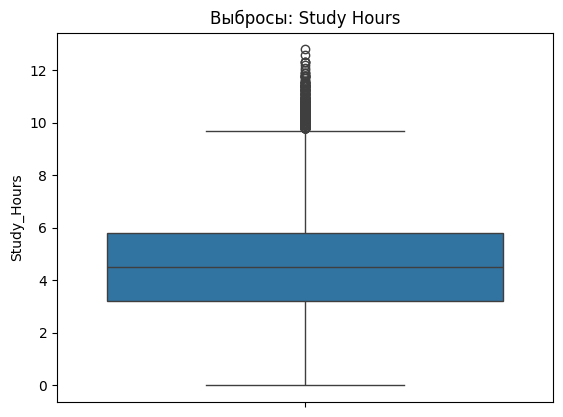

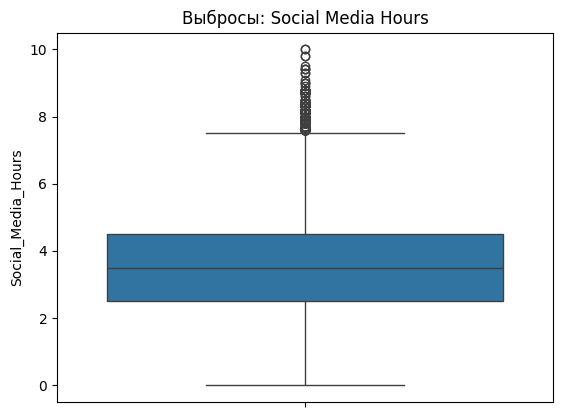

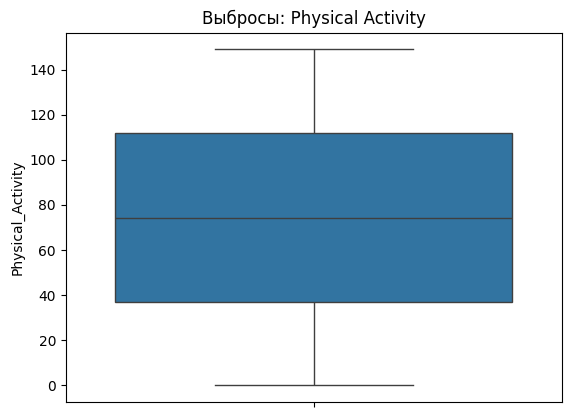

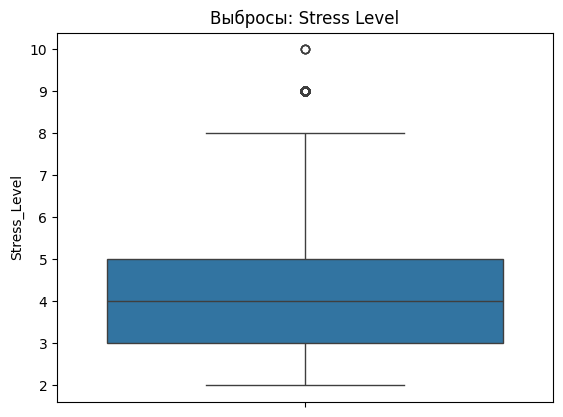

In [18]:
sns.boxplot(y=df['Study_Hours'])
plt.title('Выбросы: Study Hours')
plt.show()

sns.boxplot(y=df['Social_Media_Hours'])
plt.title('Выбросы: Social Media Hours')
plt.show()

sns.boxplot(y=df['Physical_Activity'])
plt.title('Выбросы: Physical Activity')
plt.show()

sns.boxplot(y=df['Stress_Level'])
plt.title('Выбросы: Stress Level')
plt.show()

## Итоговый вывод EDA - Выбросы

- Age: выбросов нет, диапазон 18-24 (норма для студентов)
- Sleep_Duration: выбросы 11-12 часов (~0.4%), физически возможны, оставляем
- Study_Hours: выбросы 10-13 часов, возможны в период сессии, оставляем  
- Social_Media_Hours: выбросы до 10 часов, граничные но скорее всего реальные значения
- Stress_Level: единичные значения 9 и 10 - похоже у кого-то проблемы...

# Heatmap


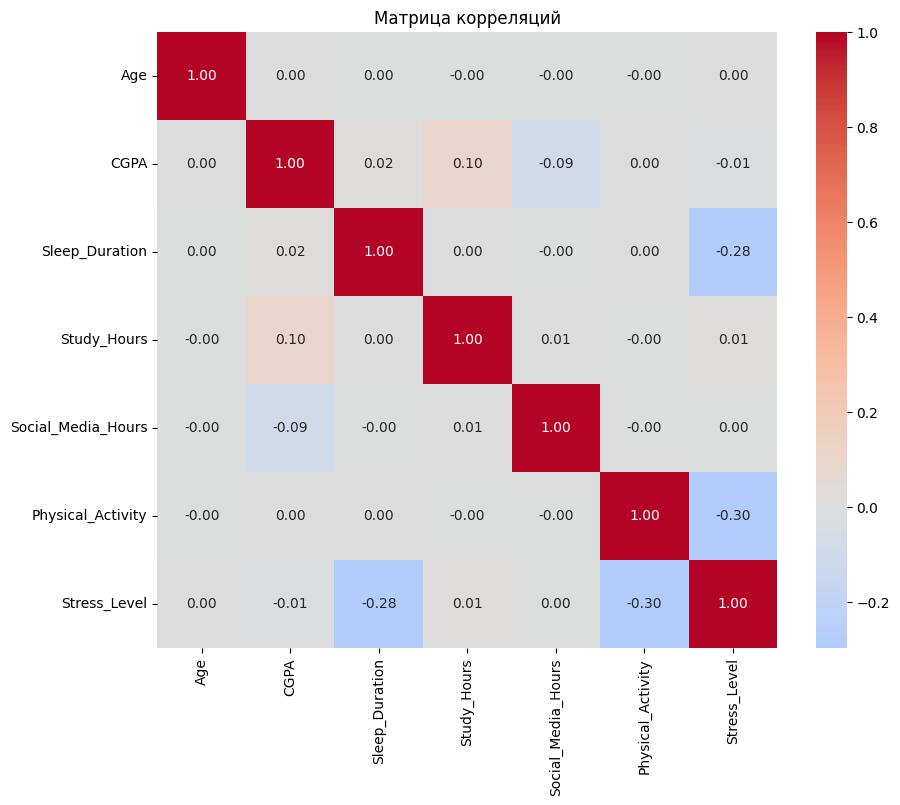

In [ ]:
num_cols = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours',
            'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.show()

# Вывод по матрице корреляций

Большинство признаков практически не коррелируют друг с другом, но есть некорые связи:

1. CGPA и Study_Hours = 0.10 - слабая положительная связь.
   Больше учишься, значит оценки немного лучше.

2. CGPA и Social_Media_Hours = -0.09 - слабая отрицательная связь.
   Больше соцсетей, следовательно чуть ниже CGPA. Тоже логично, но результат не НАСТОЛЬКО разнится

3. Sleep_Duration и Stress_Level = -0.28 - сильная связь.
   Больше стресса, значит меньше сна.

4. Physical_Activity и Stress_Level = -0.30 - самая сильная связь.
   Больше физической активности, следовательно меньше стресса

# 2. Предобработка данных

Удаляем столбец Student ID, так как он бесполезен

In [53]:
df = df.drop(columns=['Student_ID'])
print("Столбец Student_ID удалён")
print(f"Размер датасета: {df.shape}")

KeyError: "['Student_ID'] not found in axis"

 Дубликатов и пропусков нет, это мы выяснили в самом начале

# Кодирование категориальных признаков

In [20]:
print("Gender:", df['Gender'].unique())
print("Department:", df['Department'].unique())
print("Depression:", df['Depression'].unique())

Gender: ['Female' 'Male']
Department: ['Science' 'Engineering' 'Medical' 'Arts' 'Business']
Depression: [False  True]


# Depression - Label Encoding

In [54]:
df['Depression'] = df['Depression'].astype(int)
print("Depression:", df['Depression'].unique())

Depression: [0 1]


# Gender - One-Hot Encoding

In [22]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
print("Новые столбцы Gender:", [col for col in df.columns if 'Gender' in col])

Новые столбцы Gender: ['Gender_Male']


# Department - One-Hot Encoding

In [55]:
df = pd.get_dummies(df, columns=['Department'], drop_first=True)
print("Новые столбцы Department:", [col for col in df.columns if 'Department' in col])

KeyError: "None of [Index(['Department'], dtype='object')] are in the [columns]"

# Результат

In [24]:
print("\nСтолбцы датасета после кодирования:")
print(df.columns)
print(f"\nРазмер: {df.shape}")


Столбцы датасета после кодирования:
Index(['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours',
       'Physical_Activity', 'Stress_Level', 'Depression', 'Gender_Male',
       'Department_Business', 'Department_Engineering', 'Department_Medical',
       'Department_Science'],
      dtype='object')

Размер: (100000, 13)


# Feature Engineering

In [25]:
df['Sleep_Study_Ratio'] = df['Sleep_Duration'] / (df['Study_Hours'] + 0.1)
df['Total_Load'] = df['Study_Hours'] + df['Social_Media_Hours']
df['Health_Index'] = df['Sleep_Duration'] + df['Physical_Activity'] - df['Stress_Level']

# Масштабирование (импорт)

In [33]:
from sklearn.preprocessing import StandardScaler

Масштабирование будет выполнено после разбиения данных на обучающую, валидационную и тестовую выборки для предотвращения утечки данных

# 3. Отбираем релевантные признаки для обучения

In [27]:
features_regression = [
    'Sleep_Duration',
    'Study_Hours',
    'Sleep_Study_Ratio',
    'Total_Load',
    'Stress_Level',
    'Physical_Activity'
]

features_classification = [
    'Sleep_Duration',
    'Stress_Level',
    'Study_Hours',
    'Social_Media_Hours',
    'Physical_Activity',
    'Health_Index',
    'Age',
    'Gender_Male'
]

print("Признаки для регрессии:", features_regression)
print("\nПризнаки для классификации:", features_classification)

Признаки для регрессии: ['Sleep_Duration', 'Study_Hours', 'Sleep_Study_Ratio', 'Total_Load', 'Stress_Level', 'Physical_Activity']

Признаки для классификации: ['Sleep_Duration', 'Stress_Level', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Health_Index', 'Age', 'Gender_Male']


- Для регрессии упор делается на занятость, физическую активность, общую загрузку
- Для классификации упор делается на проведённом времени в интернете, уровень стресса, индекс здоровья

# 4. Разделяем данные на обучающую, валидационную и тестовую выборки

- Train - 60%
- Validation - 20%
- Test - 20%

# Код для регрессии

In [28]:
from sklearn.model_selection import train_test_split

X_reg = df[features_regression]
y_reg = df['CGPA']

X_reg_train_val, X_reg_test, y_reg_train_val, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_train_val, y_reg_train_val, test_size=0.25, random_state=42)

print("Регрессия:")
print(f"Train: {X_reg_train.shape[0]} строк")
print(f"Val:   {X_reg_val.shape[0]} строк")
print(f"Test:  {X_reg_test.shape[0]} строк")

Регрессия:
Train: 60000 строк
Val:   20000 строк
Test:  20000 строк


Для регрессии масштабируются все используемые числовые признаки

# Масштабирование (регрессия)

In [34]:
cols_reg_to_scale = X_reg_train.columns

scaler_reg = StandardScaler()

X_reg_train[cols_reg_to_scale] = scaler_reg.fit_transform(X_reg_train[cols_reg_to_scale])
X_reg_val[cols_reg_to_scale] = scaler_reg.transform(X_reg_val[cols_reg_to_scale])
X_reg_test[cols_reg_to_scale] = scaler_reg.transform(X_reg_test[cols_reg_to_scale])

# Код для классификации

In [29]:
X_cls = df[features_classification]
y_cls = df['Depression']

X_cls_train_val, X_cls_test, y_cls_train_val, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)

X_cls_train, X_cls_val, y_cls_train, y_cls_val = train_test_split(
    X_cls_train_val, y_cls_train_val, test_size=0.25, random_state=42)

print("\nКлассификация:")
print(f"Train: {X_cls_train.shape[0]} строк")
print(f"Val:   {X_cls_val.shape[0]} строк")
print(f"Test:  {X_cls_test.shape[0]} строк")


Классификация:
Train: 60000 строк
Val:   20000 строк
Test:  20000 строк


Gender Male не масштабируем, так как это бинарный признак

# Масштабирование (классификация)

In [36]:
cols_cls_to_scale = [
    'Sleep_Duration',
    'Stress_Level',
    'Study_Hours',
    'Social_Media_Hours',
    'Physical_Activity',
    'Health_Index',
    'Age'
]

scaler_cls = StandardScaler()

X_cls_train[cols_cls_to_scale] = scaler_cls.fit_transform(X_cls_train[cols_cls_to_scale])
X_cls_val[cols_cls_to_scale] = scaler_cls.transform(X_cls_val[cols_cls_to_scale])
X_cls_test[cols_cls_to_scale] = scaler_cls.transform(X_cls_test[cols_cls_to_scale])

# 5. Обучение Linear Regression

In [37]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_reg_train, y_reg_train)

LinearRegression()

Получим результаты на обучающей, валидационной и тестовой выборках

In [38]:
y_reg_train_pred = lin_reg.predict(X_reg_train)
y_reg_val_pred = lin_reg.predict(X_reg_val)
y_reg_test_pred = lin_reg.predict(X_reg_test)

Метрики для регрессии

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

def print_regression_metrics(y_true, y_pred, name):
    print(f"{name}:")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))
    print()

print_regression_metrics(y_reg_train, y_reg_train_pred, "Train")
print_regression_metrics(y_reg_val, y_reg_val_pred, "Validation")
print_regression_metrics(y_reg_test, y_reg_test_pred, "Test")

Train:
MSE: 0.2776527376584988
R2: 0.019646982721202466

Validation:
MSE: 0.27750435897571313
R2: 0.01949517238246179

Test:
MSE: 0.2788090218820065
R2: 0.017206233547930938



Значения метрик на обучающей и валидационной выборках близки, что подтверждает отсутствие переобучения модели линейной регрессии

# 6. Обучение Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_cls_train, y_cls_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [47]:
y_cls_train_pred = log_reg.predict(X_cls_train)
y_cls_val_pred = log_reg.predict(X_cls_val)
y_cls_test_pred = log_reg.predict(X_cls_test)

Также получим вероятности принадлежности к единице (положительному классу)

In [48]:
y_cls_train_proba = log_reg.predict_proba(X_cls_train)[:, 1]
y_cls_val_proba = log_reg.predict_proba(X_cls_val)[:, 1]
y_cls_test_proba = log_reg.predict_proba(X_cls_test)[:, 1]

Метрики для регрессии

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def print_classification_metrics(y_true, y_pred, y_proba, name):
    print(f"{name}:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print()

print_classification_metrics(y_cls_train, y_cls_train_pred, y_cls_train_proba, "Train")
print_classification_metrics(y_cls_val, y_cls_val_pred, y_cls_val_proba, "Validation")
print_classification_metrics(y_cls_test, y_cls_test_pred, y_cls_test_proba, "Test")

Train:
Accuracy: 0.5791833333333334
Precision: 0.11921241050119331
Recall: 0.4910699655906931
F1-score: 0.1918509746183145
ROC-AUC: 0.5621111144657247

Validation:
Accuracy: 0.57535
Precision: 0.1134885920321551
Recall: 0.49129989764585463
F1-score: 0.18438490348602707
ROC-AUC: 0.5633226517335261

Test:
Accuracy: 0.57915
Precision: 0.1130823075066377
Recall: 0.46733167082294264
F1-score: 0.18210086483334953
ROC-AUC: 0.5468127403081626



In [50]:
train_acc = accuracy_score(y_cls_train, y_cls_train_pred)
val_acc = accuracy_score(y_cls_val, y_cls_val_pred)

train_f1 = f1_score(y_cls_train, y_cls_train_pred)
val_f1 = f1_score(y_cls_val, y_cls_val_pred)

print("Точность обучения:", train_acc)
print("Точность валидации:", val_acc)
print("Разница:", abs(train_acc - val_acc))
print()

print("Обучение F1:", train_f1)
print("Валидация F1:", val_f1)
print("F1 разница:", abs(train_f1 - val_f1))

Точность обучения: 0.5791833333333334
Точность валидации: 0.57535
Разница: 0.0038333333333333552

Обучение F1: 0.1918509746183145
Валидация F1: 0.18438490348602707
F1 разница: 0.007466071132287422


# Эксперименты c learning rate и эпохами

In [52]:
from sklearn.linear_model import SGDClassifier
import pandas as pd

results = []

learning_rates = [0.001, 0.01, 0.1]
epochs_list = [100, 500, 1000]

for lr in learning_rates:
    for epochs in epochs_list:
        model = SGDClassifier(
            loss='log_loss',
            learning_rate='constant',
            eta0=lr,
            max_iter=epochs,
            class_weight='balanced',
            random_state=42
        )

        model.fit(X_cls_train, y_cls_train)

        train_pred = model.predict(X_cls_train)
        val_pred = model.predict(X_cls_val)

        train_f1 = f1_score(y_cls_train, train_pred)
        val_f1 = f1_score(y_cls_val, val_pred)

        results.append({
            'learning_rate': lr,
            'epochs': epochs,
            'train_f1': train_f1,
            'val_f1': val_f1,
            'f1_gap': abs(train_f1 - val_f1)
        })

results_df = pd.DataFrame(results)
results_df

,learning_rate,epochs,train_f1,val_f1,f1_gap
0,0.001,100,0.193382,0.186238,0.007144
1,0.001,500,0.193382,0.186238,0.007144
2,0.001,1000,0.193382,0.186238,0.007144
3,0.010,100,0.186635,0.184556,0.002079
4,0.010,500,0.186635,0.184556,0.002079
5,0.010,1000,0.186635,0.184556,0.002079
6,0.100,100,0.159099,0.157587,0.001513
7,0.100,500,0.159099,0.157587,0.001513
8,0.100,1000,0.159099,0.157587,0.001513


# Вывод

В ходе экспериментов с использованием SGDClassifier было исследовано влияние learning rate и числа эпох на качество модели

Установлено, что наилучшее качество достигается при learning rate = 0.001, где значение F1-score на валидационной выборке составляет 0.186

Разница между значениями F1-score на обучающей и валидационной выборках менее 0,01, что говорит об отсутствии переобучения

# Оценка качества моделей

Модель линейной регрессии показывает адекватные результаты и может прогнозировать CGPA с приемлемой точностью

Для классификации использовались разные метрики. Несмотря на невысокий F1-score, модель умеет находить случаи депрессии, что важно, так как таких случаев в данных меньше

# Влияние предобработки

Предобработка данных заметно повлияла на качество моделей:

Масштабирование признаков помогло моделям обучаться стабильнее и быстрее, особенно это важно для логистической регрессии

Кодирование категориальных признаков позволило использовать такие данные в обучении моделей

Созданные признаки (Sleep_Study_Ratio, Total_Load, Health_Index) добавили дополнительную информацию и помогли лучше отразить связь между образом жизни студента и его состоянием

Также важным шагом было учёт дисбаланса классов с помощью параметра (class_weight='balanced'). Без этого модель практически не определяла случаи депрессии, а после применения этого параметра качество классификации стало более осмысленным

# Краткий отчёт по лабе

В процессе выполнения работы возникли некоторые трудности, связанные с особенностями данных и настройкой моделей (ну и честно, лаба довольно объёмная и столько всего нового)

Сначала возникла проблема с масштабированием - изначально оно было применено ко всему датасету до разбиения, что приводило к утечке данных. После исправления и переноса масштабирования на этап после разделения выборок пайплайн стал корректным

Также сложность вызвал дисбаланс классов в задаче классификации. Без его учета модель показывала высокую точность, но при этом не выявляла случаи депрессии (F1-score был равен нулю). После добавления параметра class_weight='balanced' результаты стали более осмысленными

Кроме того, при проведении экспериментов с SGDClassifier модель сначала давала почти нулевые результаты, что также было связано с игнорированием  класса. После добавления параметра class_weight='balanced' удалось получить более адекватные значения метрик

В целом основные трудности были связаны не с реализацией кода (но и они тоже были, лаба правда большая), а с правильной интерпретацией результатов и пониманием того, как разные этапы предобработки и настройки влияют на качество моделей.